# KMeans Clustering Tutorial
This tutorial demonstrates how to use the Lexos `KMeansCluster` module with a preprocessed document-term matrix (DTM). You will learn how to perform clustering, visualize the results, and export your outputs for further analysis.

# Table of Contents

Use this list to navigate through the tutorial.

1. [Step 0: Import Required Libraries](#step-0-import-required-libraries)
2. [Step 1: Load Your Text Files](#step-1-load-your-text-files)
3. [Step 2: Build the Document-Term Matrix (DTM)](#step-2-build-the-document-term-matrix-dtm)
4. [Step 3: Set Up a Folder to Save Your Results](#step-3-set-up-a-folder-to-save-your-results)
5. [Step 4: Initialize the KMeans Clustering Tool](#step-4-initialize-the-kmeans-clustering-tool)
6. [Optional: Customize KMeans Settings](#optional-customize-kmeans-settings)
7. [Step 5: Choose the Best Number of Clusters (k)](#step-5-choose-the-best-number-of-clusters-k)
8. [Step 6: Run the Clustering with Your Chosen k](#step-6-run-the-clustering-with-your-chosen-k)
9. [Step 7: Visualize Clusters in 2D (PCA)](#step-7-visualize-clusters-in-2d-pca)
10. [Step 8: Visualize Clusters in 3D (PCA)](#step-8-visualize-clusters-in-3d-pca)
11. [Step 9: Visualize Decision Regions with a Voronoi Diagram](#step-9-visualize-decision-regions-with-a-voronoi-diagram)

## Step 0: Import Required Libraries

Before we begin, we need to import the necessary Python libraries. These include:

- `KMeansCluster` from the Lexos clustering module, which performs the clustering.
- `DTM` to handle our document-term matrix.
- `Path` from Python’s built-in `pathlib` module to help manage folder paths in a clean, cross-platform way.
- `spaCy`, a natural language processing tool that helps us clean and process the text data.

These tools work together to prepare, cluster, and visualize your documents.

In [1]:
from lexos.cluster.kmeans import KMeansCluster
from lexos.dtm import DTM
from pathlib import Path
import spacy

In [2]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length  = 2_000_000

## Step 1: Load Your Text Files

In this step, we load all the text files that you want to cluster. Each file is treated as one document.

The code looks for `.txt` files in the `FilesToUse` folder, reads the contents of each file, and stores both:
- The actual words (as a list)
- The name of each file (as a label)

You'll see confirmation of how many documents were loaded and their filenames.

In [3]:
base_dir = Path.cwd().parent / "FilesToUse"
file_paths = sorted(base_dir.glob("*.txt"))

docs = []
labels = []

for path in file_paths:
    with open(path, "r", encoding="utf-8") as f:
        docs.append(f.read().split())
        labels.append(path.stem)

print(f"Loaded {len(docs)} documents:", labels)

Loaded 8 documents: ['AI_The_Hermit', 'AI_The_Invention', 'HenryWP_ThePirate', 'HenryWP_ThePirate_Short', 'Irving_RipVanWInkle', 'Lippard_BelOfPrairieEden', 'Melville_MobyDick', 'Poe_FallOfHouseUsher_1839']


## Step 2: Build the Document-Term Matrix (DTM)

Now we turn our loaded text documents into a Document-Term Matrix (DTM) using the Lexos `DTM` class.

Each row in the DTM represents a word, and each column represents a document. The values inside the matrix tell us how important each word is in each document.

We customize how the matrix is built using the following settings:

- `tf_type="linear"`: Uses raw term frequencies (how often a word appears).
- `idf_type="smooth"`: Reduces the impact of words that appear in many documents.
- `norm="l2"`: Normalizes values for fair comparison across different-length documents.
- `min_df=2`: Removes words that appear in fewer than 2 documents.
- `max_n_terms=100`: Keeps only the top 100 most important terms.

The `.to_df()` function converts the matrix into a readable table.

In [4]:
dtm = DTM(
    tf_type = "linear",
    idf_type = "smooth",
    norm="l2",
    min_df=2,
    max_n_terms=100,
)

dtm(docs=docs, labels=labels)

df = dtm.to_df()

df.head()

,AI_The_Hermit,AI_The_Invention,HenryWP_ThePirate,HenryWP_ThePirate_Short,Irving_RipVanWInkle,Lippard_BelOfPrairieEden,Melville_MobyDick,Poe_FallOfHouseUsher_1839
old,0,0.102011,0.004699,0,0.045104,0.008604,0.02565,0.005688
then,0,0.102011,0.009398,0,0.011276,0.011894,0.036693,0.005688
them,0,0,0.021112,0,0.02714,0.010801,0.030516,0.006389
their,0,0,0.005278,0,0.054279,0.045478,0.039638,0.01757
than,0,0,0.015834,0,0.007237,0.008527,0.019819,0.01757


## Step 3: Set Up a Folder to Save Your Results

Before we run clustering and create visualizations, we’ll create a folder where all the output files (like plots and CSVs) can be saved.

This folder is called `kmeans_outputs`, and it will appear in the same location as your notebook. The `exist_ok=True` argument makes sure the code doesn't break if the folder already exists.

In [5]:
# Create a folder to save plots and CSVs (if it doesn't already exist)
save_dir = Path.cwd() / "kmeans_outputs"
save_dir.mkdir(exist_ok=True)

## Step 4: Initialize the KMeans Clustering Tool

Now we’re ready to set up the KMeans clustering model from Lexos. This tool will analyze your document-term matrix and group the documents into clusters based on how similar their word usage is.

Here, we create a `KMeansCluster` object and connect it to the DTM we created earlier.

In [6]:
# Create the clustering object using default settings
kmeans = KMeansCluster()

# Attach the DTM (document-term matrix) we built earlier
kmeans.dtm = dtm

## Optional: Customize KMeans Settings

The `KMeansCluster` class allows you to fine-tune how the clustering is performed by setting these optional parameters:

- **`k`**: *(int)* The number of clusters. If you skip this when creating the object, you'll need to pass it later like `kmeans(k=4)`.
- **`init`**: *(str)* Method to initialize centroids. Options:
  - `"k-means++"` (default): Smart initialization for better accuracy.
  - `"random"`: Completely random centroids.
- **`max_iter`**: *(int)* Maximum number of iterations. Default is `300`.
- **`n_init`**: *(int)* Number of different centroid seeds to try. Default is `10`. Helps avoid poor local minima.
- **`tol`**: *(float)* Relative tolerance for convergence. Default is `0.0001`.

These parameters can be set when you create the model:

```python
kmeans = KMeansCluster(k=4, init="random", max_iter=500, n_init=20, tol=1e-3)

## Step 5: Choose the Best Number of Clusters (k)

Before we group the documents, we want to decide how many clusters (k) makes the most sense. One way to do this is by using an elbow plot.

The elbow plot shows how much better the clustering gets as we increase `k`. At some point, the improvement slows down — this point is called the elbow, and it’s usually a good choice for `k`.

Running elbow plot for k = 1 to 8 (limited to document count)


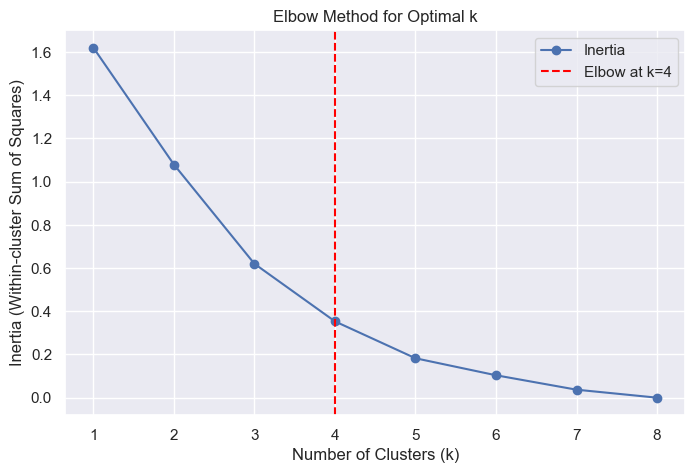

In [7]:
kmeans.elbow_plot(k_range=range(1, 10))

## Step 6: Run the Clustering with Your Chosen k

Now that we’ve identified the best number of clusters (k) from the elbow plot, we can run the KMeans clustering.

Here, we use `k=4` based on the elbow point. This means we are asking the algorithm to divide our documents into 4 groups.

The result is a list of cluster labels, where each number represents the cluster assigned to one of your documents (in the same order they were loaded earlier). 

In [8]:
# Run clustering with k=4 (you can change this value as needed)
# The output is a list of cluster labels, one per document
kmeans(k=4)

array([0, 2, 3, 3, 1, 1, 1, 1])

## Step 7: Visualize Clusters in 2D (PCA)

This plot reduces the document-term matrix down to two dimensions using PCA (Principal Component Analysis), and shows how the documents are grouped into clusters. Each dot is a document, and colors represent clusters.

You can:
- View the interactive plot in the notebook
- Save the plot as a PNG or SVG
- Export a CSV file that shows the coordinates and cluster assignments for each document

This is a great way to get a quick visual overview of your clustered data.

In [9]:
# Create a 2D scatter plot using PCA-reduced coordinates
# Each point is a document colored by its cluster
kmeans.plot_2d(show=True)

In [10]:
kmeans.save_png(save_dir / "kmeans_2d_plot.png")
kmeans.save_svg(save_dir / "kmeans_2d_plot.svg")
kmeans.export_csv(save_dir / "kmeans_2d_clusters.csv")
print("Saved 2D PNG, SVG, and CSV to:", save_dir)

Saved 2D PNG, SVG, and CSV to: d:\Downloads\Lexos\uv_lexos\src\lexos\cluster\kmeans\kmeans_outputs


## Step 8: Visualize Clusters in 3D (PCA)

This 3D version gives you a more nuanced view of how your documents are spread out across clusters. It uses three principal components instead of two.

Just like with the 2D plot, you can:
- Interact with the plot (rotate, zoom)
- Save as PNG or SVG
- Export the cluster assignments and PCA coordinates to CSV

Use this view if your clusters seem too close together in 2D and you want a deeper perspective.

In [11]:
# Create a 3D scatter plot to show clusters in more space
kmeans.plot_3d(show=True)

In [12]:
kmeans.save_png(save_dir / "kmeans_3d_plot.png")
kmeans.save_svg(save_dir / "kmeans_3d_plot.svg")
kmeans.export_csv(save_dir / "kmeans_3d_clusters.csv")
print("Saved 3D PNG, SVG, and CSV to:", save_dir)

Saved 3D PNG, SVG, and CSV to: d:\Downloads\Lexos\uv_lexos\src\lexos\cluster\kmeans\kmeans_outputs


## Step 9: Visualize Decision Regions with a Voronoi Diagram

This Voronoi plot shows how the clustering algorithm "divides" the PCA-reduced 2D space into decision regions.

Each colored area represents the region closest to one of the cluster centroids. The black X's mark the calculated centroids. Your documents are plotted as colored dots based on which cluster they belong to.

This visualization is useful for understanding how clearly separated your clusters are — especially when the groups overlap or are close together.

In [13]:
# Generate a Voronoi plot showing decision regions
# This helps visualize which areas belong to which cluster
kmeans.plot_voronoi(show=True)

Grid step auto-adjusted to 0.01 to avoid memory overload.
